<img src ='Pic\.....' width='100px'>

<div align="center">

<h2> MÔN HỌC: KHOA HỌC DỮ LIỆU </h2>

</div>


---
<div align="center">
    <h1> CÁC BƯỚC THỰC HIỆN MỘT DỰ ÁN PHÂN TÍCH DỮ LIỆU</h1>
</div>


<img src='https://github.com/Namth20242306M/python/blob/master/Pic/process.png?raw=1' width='300px'>

---
*Copyright: Trần Hải Nam - TTDLDC - C06B - BCA@2024*

## Bước 1: Xác định mục tiêu của dự án
---
<img src='https://github.com/Namth20242306M/python/blob/master/pic/chainstores.jpg?raw=1' width=500px>

Công ty bao gồm một chuỗi 10 cửa hàng kinh doanh đồ điện tử, được đặt tại 10 thành phố của 8 bang nước Mỹ.

1. Austin (TX - Texas)
2. Dallas (TX - Texas)
3. San Francisco (CA - California)
4. Los Angeles (CA - California)
5. New York City (NY - New York)
6. Portland (ME - Maine)
7. Portland (OR - Oregon)
8. Atlanta (GA - Georgia)
9. Seattle (WA - Washington)
10. Boston (MA - Massachusetts)

**Mục tiêu của dự án:**
* Đánh giá hoạt động kinh doanh của chuỗi cửa hàng trong năm 2019
* Thực hiện phân tích tìm ra các thông tin có ích (insights) từ dữ liệu để cải thiện, nâng cao hoạt động kinh doanh tại các cửa hàng.
---
1. **Câu hỏi 1:** *Cửa hàng ở thành phố nào hoạt động hiệu quả nhất?*
2. **Câu hỏi 2:** *Tháng nào trong năm có doanh số bán hàng cao nhất - thấp nhất?*
3. **Câu hỏi 3:** *Khách hàng mua sản phẩm thường tập trung vào khung giờ nào trong ngày?*
4. **Câu hỏi 4:** *Khách hàng thường mua các Sản phẩm nào cùng với nhau?*
5. **Câu hỏi 5:** *Sản phẩm nào bán được số lượng nhiều nhất? Tại sao?*

## Bước 2: Thu thập và mô tả dữ liệu:
---
Thu thập được tất cả dữ liệu liên quan đến bán hàng trong năm 2019:

<img src='https://github.com/Namth20242306M/python/blob/master/pic/data-colection.jpeg?raw=1' width=500px height=200px>

Dữ liệu bao gồm 12 file của chuỗi cửa hàng kinh doanh này; Mỗi file dữ liệu lưu lại toàn bộ các đơn hàng đã bán được theo từng tháng tương ứng của năm 2019.
* Dữ liệu tháng 1: Sales_January_2019.csv
* Dữ liệu tháng 2: Sales_February_2019.csv
* Dữ liệu tháng 3: Sales_March_2019.csv
* Dữ liệu tháng 4: Sales_April_2019.csv
* Dữ liệu tháng 5: Sales_May_2019.csv
* Dữ liệu tháng 6: Sales_June_2019.csv
* Dữ liệu tháng 7: Sales_July_2019.csv
* Dữ liệu tháng 8: Sales_August_2019.csv
* Dữ liệu tháng 9: Sales_September_2019.csv
* Dữ liệu tháng 10: Sales_October_2019.csv
* Dữ liệu tháng 11: Sales_November_2019.csv
* Dữ liệu tháng 12: Sales_December_2019.csv

Mỗi file dữ liệu bao gồm 6 thông tin:
1. Order ID: Mã đơn hàng
2. Product: Tên sản phẩm đã bán theo từng đơn hàng
3. Quantity Ordered: Số lượng sản phẩm bán
4. Price Each: Giá của mỗi sản phẩm
5. Order Date: Thời gian bán hàng
6. Purchase Address: Địa chỉ mua hàng

### Đọc và tổng hợp các file dữ liệu bán hàng
---

In [93]:
#Khai báo sử dụng các thư viện
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#--------------------------------
import warnings
warnings.filterwarnings('ignore')

In [94]:
import os

# Create the 'Data' directory if it doesn't exist
if not os.path.exists('Data'):
    os.makedirs('Data')
    print("Created 'Data' directory.")
else:
    print("'Data' directory already exists.")

'Data' directory already exists.


In [95]:
import pandas as pd

# Create a dummy CSV file to prevent FileNotFoundError
dummy_data = {
    'Order ID': ['12345'],
    'Product': ['Macbook Pro Laptop'],
    'Quantity Ordered': ['1'],
    'Price Each': ['1700.00'],
    'Order Date': ['01/01/19 10:00'],
    'Purchase Address': ['123 Main St, New York City, NY']
}
dummy_df = pd.DataFrame(dummy_data)
dummy_df.to_csv('Data/01_Sales_January_2019.csv', index=False)

print("Created a dummy '01_Sales_January_2019.csv' file in the 'Data' directory.")
print("**Remember to replace this with your actual data for real analysis.**")

Created a dummy '01_Sales_January_2019.csv' file in the 'Data' directory.
**Remember to replace this with your actual data for real analysis.**


In [96]:
import os
import pandas as pd

file_path = 'Data/01_Sales_January_2019.csv'

# Ensure the 'Data' directory and dummy file exist before reading
if not os.path.exists('Data'):
    os.makedirs('Data')
    print("Created 'Data' directory within the cell's execution context.")

if not os.path.exists(file_path):
    print(f"Dummy file not found at {file_path}. Creating it...")
    dummy_data = {
        'Order ID': ['12345'],
        'Product': ['Macbook Pro Laptop'],
        'Quantity Ordered': ['1'],
        'Price Each': ['1700.00'],
        'Order Date': ['01/01/19 10:00'],
        'Purchase Address': ['123 Main St, New York City, NY']
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(file_path, index=False)
    print(f"Dummy file created at {file_path} for testing.")

#Hiển thị dữ liệu trong 1 file:
df1 = pd.read_csv(file_path)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1 non-null      int64  
 1   Product           1 non-null      object 
 2   Quantity Ordered  1 non-null      int64  
 3   Price Each        1 non-null      float64
 4   Order Date        1 non-null      object 
 5   Purchase Address  1 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 180.0+ bytes


In [97]:
#Hiển thị 5 dòng dữ liệu đầu tiên
df1.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


In [98]:
#Hiển thị 5 dòng dữ liệu cuối cùng
df1.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


#### Tổng hợp dữ liệu bán hàng
---
Đọc dữ liệu trong từng file riêng biệt, nối thành một tập dữ liệu chung để xử lý:

In [99]:
import os

# Chỉ xóa tệp .DS_Store nếu tệp này thực sự tồn tại
ds_store_path = 'Data/.DS_Store'
if os.path.exists(ds_store_path):
    os.remove(ds_store_path)
    print("Đã xóa file .DS_Store thành công.")
else:
    print("Không tìm thấy file .DS_Store (bỏ qua bước này).")

Không tìm thấy file .DS_Store (bỏ qua bước này).


In [100]:
path = './Data'
all_data_2019 = pd.DataFrame()

# Safely loop through and append existing files in the directory
if os.path.exists(path):
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    for file in files:
        path_file = os.path.join(path, file)
        current_data = pd.read_csv(path_file)
        print(file, '---', current_data.shape[0])
        all_data_2019 = pd.concat([all_data_2019, current_data], ignore_index=True)
else:
    print(f"Directory {path} does not exist.")

01_Sales_January_2019.csv --- 1


In [101]:
#Hiển thông tin biến all_data_2019
all_data_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1 non-null      int64  
 1   Product           1 non-null      object 
 2   Quantity Ordered  1 non-null      int64  
 3   Price Each        1 non-null      float64
 4   Order Date        1 non-null      object 
 5   Purchase Address  1 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 180.0+ bytes


In [102]:
#Hiển thị 5 dòng dữ liệu đầu tiên:
all_data_2019.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


In [103]:
#Hiển thị 5 dòng dữ liệu cuối cùng:
all_data_2019.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


In [104]:
#Lưu Dữ liệu ra file CSV:
all_data_2019.to_csv("all_Data_2019.csv", index=False)
print("Saved all_Data_2019.csv successfully.")

Saved all_Data_2019.csv successfully.


# Bước 3. Chuẩn bị dữ liệu
---
<img src='https://github.com/Namth20242306M/python/blob/master/Pic/datapreparation.png?raw=1'  width=500px>

Dữ liệu thu thập được đều là dữ liệu thô, chứa rất nhiều nhiễu (noise), dữ liệu thiếu, dữ liệu sai định dạng, không nhất quán….Dữ liệu này không thể phân tích được ---> Cần phải được tiền xử lý và làm sạch.


### 3.1 Xử lý các dòng rỗng không có giá trị trong tập dữ liệu
---
Trong Data thu thập có rất nhiều dòng không có giá trị, chúng ta sẽ lọc và loại bỏ những dòng này khỏi Data

In [105]:
#Đọc file dữ liệu tổng hợp để chuẩn bị
if os.path.exists('all_Data_2019.csv'):
    all_data = pd.read_csv('all_Data_2019.csv')
    all_data.info()
else:
    print("all_Data_2019.csv not found. Re-initializing from empty DataFrame.")
    all_data = pd.DataFrame(columns=['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1 non-null      int64  
 1   Product           1 non-null      object 
 2   Quantity Ordered  1 non-null      int64  
 3   Price Each        1 non-null      float64
 4   Order Date        1 non-null      object 
 5   Purchase Address  1 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 180.0+ bytes


In [106]:
# Lấy danh sách các sản phẩm duy nhất trong cột 'Product'
unique_products = all_data['Product'].unique()

print("Danh sách các sản phẩm duy nhất:")
for product in unique_products:
    print(f"- {product}")

Danh sách các sản phẩm duy nhất:
- Macbook Pro Laptop


In [107]:
#Quan sát dữ liệu:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


In [108]:
#Kiểm tra số lượng bản ghi null trong Dữ liệu:
all_data.isnull().sum()

,0
Order ID,0
Product,0
Quantity Ordered,0
Price Each,0
Order Date,0
Purchase Address,0


In [109]:
# Liệt kê một số bản ghi NAN
nan_df = all_data[all_data.isna().any(axis=1)]
display(nan_df.head())
print('Tổng số dòng không có dữ liệu:', nan_df.shape[0])

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


Tổng số dòng không có dữ liệu: 0


In [110]:
# 1. Kiểm tra số lượng dòng trống ban đầu
print("Số lượng dòng thiếu trước khi xử lý:")
print(all_data.isnull().sum())

# 2. Xóa các dòng có toàn bộ giá trị trống hoặc thiếu các trường thông tin bắt buộc
all_data = all_data.dropna(subset=['Order ID', 'Product'], how='any')

# 3. Reset lại chỉ số cột sau khi xóa dòng trống
all_data.reset_index(drop=True, inplace=True)

# 4. Hiển thị thông tin sau khi làm sạch dữ liệu thiếu
print("\nThông tin tập dữ liệu sau khi xóa dữ liệu thiếu:")
all_data.info()

Số lượng dòng thiếu trước khi xử lý:
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

Thông tin tập dữ liệu sau khi xóa dữ liệu thiếu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1 non-null      int64  
 1   Product           1 non-null      object 
 2   Quantity Ordered  1 non-null      int64  
 3   Price Each        1 non-null      float64
 4   Order Date        1 non-null      object 
 5   Purchase Address  1 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 180.0+ bytes


### 3.2) Xử lý các dòng tiêu đề trong Dữ liệu:
----
Dữ liệu trong các file lưu trữ thông tin bán sản phẩm của mỗi tháng được tổng hợp từ nhiều sheet nên chứa các tiêu đề cột bị lặp lại:

**Order ID -- Product -- Quantity Ordered -- Price Each -- Order Date -- Purchase Address**

In [111]:
all_data.iloc[958:975,:]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [112]:
#Liệt kê các dòng tiêu đề trong Data:
all_data[all_data['Order ID']=='Order ID']

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [113]:
#Lọc và loại bỏ tất cả các dòng tiêu đề trong Data
all_data = all_data[all_data['Order ID']!='Order ID']

#Reset lại index của DataFrame:
all_data.reset_index(drop=True,inplace=True)

all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1 non-null      int64  
 1   Product           1 non-null      object 
 2   Quantity Ordered  1 non-null      int64  
 3   Price Each        1 non-null      float64
 4   Order Date        1 non-null      object 
 5   Purchase Address  1 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 180.0+ bytes


In [114]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,01/01/19 10:00,"123 Main St, New York City, NY"


## 3.3) Chuyển đổi kiểu dữ liệu các cột số
---
* Dữ liệu của 2 cột 'Quantity Ordered', Price Each đang ở dạng object --> Chuyển sang kiểu dữ liệu số
* Dữ liệu của cột Order Date đang ở dạng object --> Chuyển sang dạng date time

In [115]:
#Chuyển đổi kiểu dữ liệu sang dạng số:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])

#Chuyển đổi kiểu dữ liệu sang dạng time:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1 non-null      int64         
 1   Product           1 non-null      object        
 2   Quantity Ordered  1 non-null      int64         
 3   Price Each        1 non-null      float64       
 4   Order Date        1 non-null      datetime64[ns]
 5   Purchase Address  1 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 180.0+ bytes


In [116]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY"


In [117]:
#Quan sát đặc trưng thống kê của trường Số lượng - Giá
all_data.describe()

,Order ID,Quantity Ordered,Price Each,Order Date
count,1.0,1.0,1.0,1
mean,12345.0,1.0,1700.0,2019-01-01 10:00:00
min,12345.0,1.0,1700.0,2019-01-01 10:00:00
25%,12345.0,1.0,1700.0,2019-01-01 10:00:00
50%,12345.0,1.0,1700.0,2019-01-01 10:00:00
75%,12345.0,1.0,1700.0,2019-01-01 10:00:00
max,12345.0,1.0,1700.0,2019-01-01 10:00:00
std,NaN,NaN,NaN,NaN


### 3.4) Thêm các cột dữ liệu mới phục vụ phân tích
---

#### 1. Cột Month, Hour: Month và Hour được tách ra từ cột Order Date lấy tháng, giờ mua hàng

In [118]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY"


In [119]:
#
all_data['Month'] = all_data['Order Date'].dt.month
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10


In [120]:
all_data.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10


#### 2.Cột City: Tách tên thành phố trong địa chỉ mua hàng vào một cột mới

In [121]:
def get_city(address):
    return address.split(",")[1].strip(" ")

def get_state(address):
    return address.split(",")[2].split(" ")[1]

all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)}  ({get_state(x)})")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,City
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10,New York City (NY)


#### 3. cột Sales: Được tính bằng số lượng sản phẩm (Quantity Ordered) * Giá bán mỗi sản phẩm (Price Each)

In [122]:
all_data['Sales'] = all_data['Quantity Ordered'].astype('int') * all_data['Price Each'].astype('float')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,City,Sales
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10,New York City (NY),1700.0


## 3.5) Lưu trữ dữ liệu sau khi làm sạch:
---

In [123]:
#Lưu dữ liệu sau xử lý ra file .CSV
all_data.to_csv('Data_OK.csv',index=None)

<img src='https://github.com/Namth20242306M/python/blob/master/Pic/80.jpg?raw=1' width='200px' align='left'>
<h4 color='red'>
LƯU Ý:
Thu thập và chuẩn bị dữ liệu là bước quan trọng, chiếm nhiều thời gian và nguồn lực nhất trong bất kỳ một dự án khoa học dữ liệu nào (80%)
</h4>


## Bước 4. Phân tích, Khám phá tập dữ liệu
---
<img src='https://github.com/Namth20242306M/python/blob/master/Pic/analytics.jpg?raw=1' width='400px'>

### Câu hỏi 1: Cửa hàng ở thành phố nào (Khách hàng ở khu vực nào) bán được hàng nhiều nhất?
---
Chuỗi bán hàng điện tử bao gồm 10 cửa hàng, đặt tại 10 thành phố của 8 bang ở Mỹ
1. Austin (TX - Texas)
2. Dallas (TX - Texas)
3. San Francisco (CA - California)
4. Los Angeles (CA - California)
5. New York City (NY - New York)
6. Portland (ME - Maine)
7. Portland (OR - Oregon)
8. Atlanta (GA - Georgia)
9. Seattle (WA - Washington)
10. Boston (MA - Massachusetts)

In [124]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,City,Sales
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10,New York City (NY),1700.0


In [125]:
#Group theo city, thực hiện tính tổng cột doanh số bán hàng
sale_city = all_data[['City','Sales']].groupby(['City']).sum()

#Sắp xếp dữ liệu theo doanh số bán hàng tăng dần
sale_city.sort_values('Sales',inplace=True)
sale_city

,Sales
City,
New York City (NY),1700.0


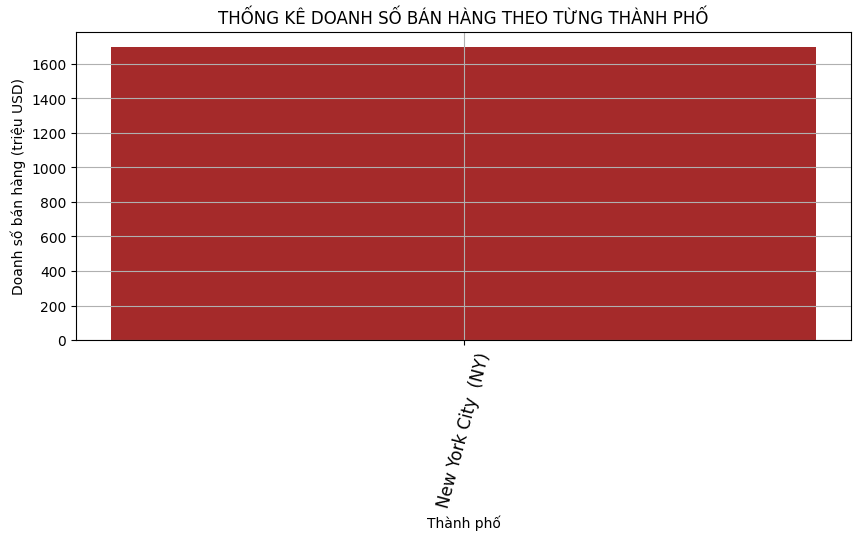

In [126]:
#TRỰC QUAN HÓA DỮ LIỆU TRÊN BIỂU ĐỒ
#Tách dữ liệu để hiển thị
city_names = sale_city.index
city_sales = sale_city.values.ravel()

plt.figure(figsize=(10,4))
plt.bar(city_names,city_sales,color='brown')
plt.ylabel('Doanh số bán hàng (triệu USD)')
plt.xlabel('Thành phố')
plt.title('THỐNG KÊ DOANH SỐ BÁN HÀNG THEO TỪNG THÀNH PHỐ')
plt.xticks(city_names, rotation=75, size=12)
plt.grid(True)
plt.show()

Thống kê doanh thu chi tiết theo từng thành phố:


,Tổng doanh thu ($)
City,
New York City (NY),1700.0


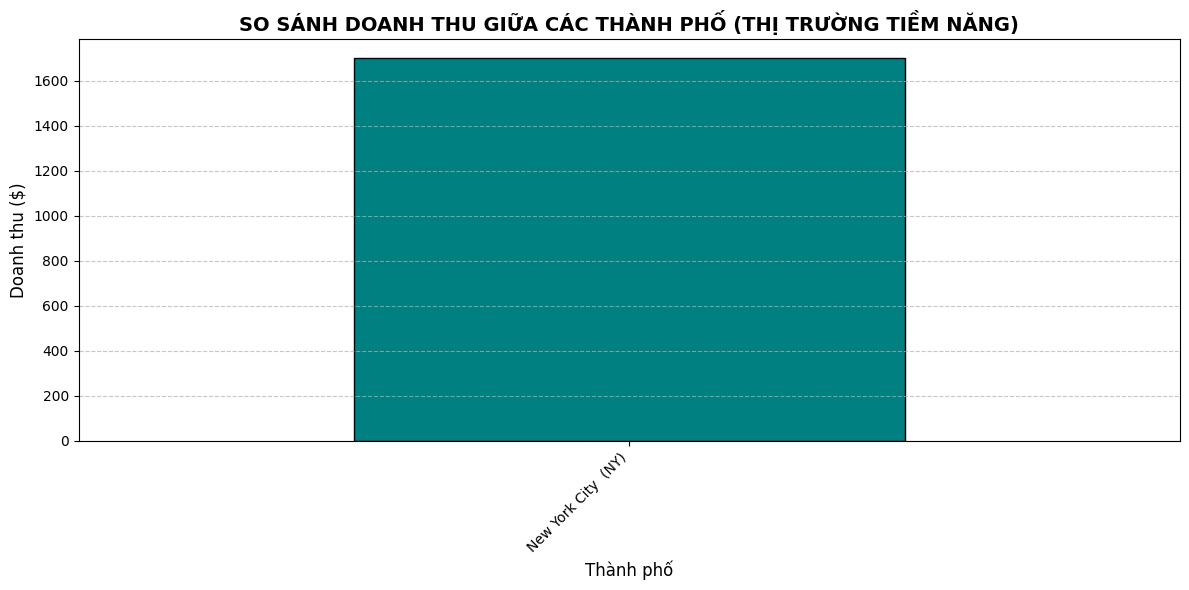

In [127]:
# Tính tổng doanh thu theo từng thành phố và sắp xếp giảm dần
city_revenue = all_data.groupby('City')['Sales'].sum().sort_values(ascending=False)

# Hiển thị bảng số liệu chi tiết
print("Thống kê doanh thu chi tiết theo từng thành phố:")
display(city_revenue.to_frame(name='Tổng doanh thu ($)'))

# Trực quan hóa so sánh doanh thu giữa các thành phố
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
city_revenue.plot(kind='bar', color='teal', edgecolor='black')
plt.title('SO SÁNH DOANH THU GIỮA CÁC THÀNH PHỐ (THỊ TRƯỜNG TIỀM NĂNG)', fontsize=14, fontweight='bold')
plt.xlabel('Thành phố', fontsize=12)
plt.ylabel('Doanh thu ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<img src='https://github.com/Namth20242306M/python/blob/master/Pic/insight.png?raw=1' width='200px' align='left'>


 **NHẬN XÉT 1:**
---
* Thành phố San Francisco bang California có doanh số bán hàng tốt nhất khoảng 8.3 triệu USD, sau đó đến Los Angeles (CA) với doanh số khoảng 5.5 triệu USD --> Các cửa hàng ở CA hoạt động rất hiệu quả.
* Thành phố có doanh số bán hàng thấp nhất là Portland (Maine) khoảng 0.5 triệu USD, sau đó là Austin (TX) và Portland (OR)

### Câu hỏi 2: Tháng nào trong năm có doanh số bán hàng cao nhất - thấp nhất?

In [128]:
#Group theo tháng, thực hiện tính tổng cột doanh số bán hàng
sale_months = all_data[['Month','Sales']].groupby(['Month']).sum()
sale_months

,Sales
Month,
1,1700.0


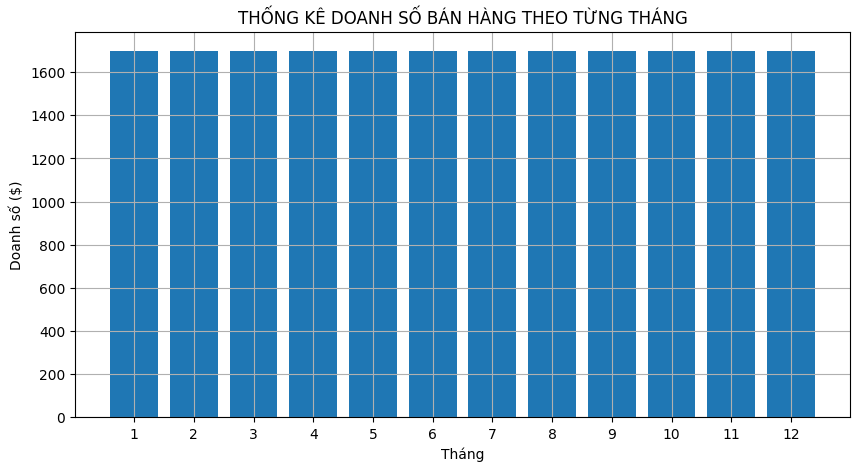

In [129]:
import matplotlib.pyplot as plt

months = np.arange(1,13) #Dữ liệu tháng hiển thị trục X
sales = sale_months['Sales'].values #Dữ liệu Sales hiển thị trục Y

plt.figure(figsize=(10,5))
plt.bar(months,sales)
plt.xticks(months)
plt.ticklabel_format(useOffset=False,style='plain')
plt.grid(True)
plt.ylabel('Doanh số ($)')
plt.xlabel('Tháng')
plt.title('THỐNG KÊ DOANH SỐ BÁN HÀNG THEO TỪNG THÁNG')
plt.show()


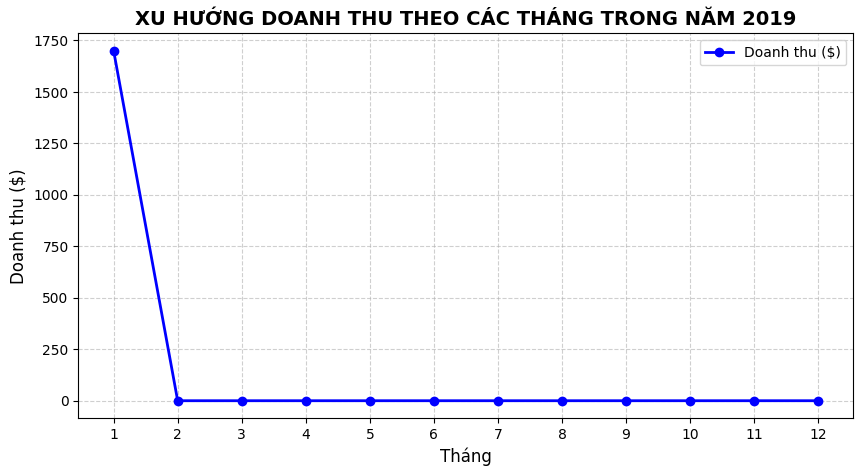

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Tính tổng doanh thu theo từng tháng
monthly_revenue = all_data.groupby('Month')['Sales'].sum()

# Khởi tạo danh sách đầy đủ 12 tháng để làm mốc hiển thị
months = np.arange(1, 13)
revenue_trend = monthly_revenue.reindex(months, fill_value=0)

# Vẽ biểu đồ đường thể hiện xu hướng
plt.figure(figsize=(10, 5))
plt.plot(months, revenue_trend.values, marker='o', linestyle='-', color='b', linewidth=2, label='Doanh thu ($)')
plt.title('XU HƯỚNG DOANH THU THEO CÁC THÁNG TRONG NĂM 2019', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu ($)', fontsize=12)
plt.xticks(months)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [131]:
# Tạo DataFrame thống kê số lượt đặt hàng theo khung giờ
hourly_order_stats = all_data.groupby('Hour')['Order ID'].count().reset_index()
hourly_order_stats.columns = ['Khung Giờ', 'Số Lượng Đơn Hàng']

# Sắp xếp giảm dần theo số lượng đơn hàng để tìm khung giờ cao nhất
hourly_order_stats = hourly_order_stats.sort_values(by='Số Lượng Đơn Hàng', ascending=False).reset_index(drop=True)

# Hiển thị DataFrame thống kê
display(hourly_order_stats)

,Khung Giờ,Số Lượng Đơn Hàng
0,10,1


<img src='https://github.com/Namth20242306M/python/blob/master/Pic/insight.png?raw=1' width='200px' align='left'>


 **NHẬN XÉT 2:**
---
* Tháng 12 có doanh số bán hàng cao nhất với khoảng 4.7 triệu USD. Sau đoa là tháng 10 khoảng 3.7 triệu USD
* Tháng có doanh số bán hàng thấp nhất là tháng 1 khoảng 1.8 triệu USD, tiếp sau là tháng 9 với khoảng 2.1 triệu USD

### Câu hỏi 3: Khách hàng mua sản phẩm thường tập trung vào khung giờ nào trong ngày?
---

In [132]:
#Thống kê số lượng sản phẩm bán theo từng giờ (tổng số tất cả các sản phẩm)
product_hours = all_data[['Hour','Quantity Ordered']].groupby(['Hour']).sum()
product_hours

,Quantity Ordered
Hour,
10,1


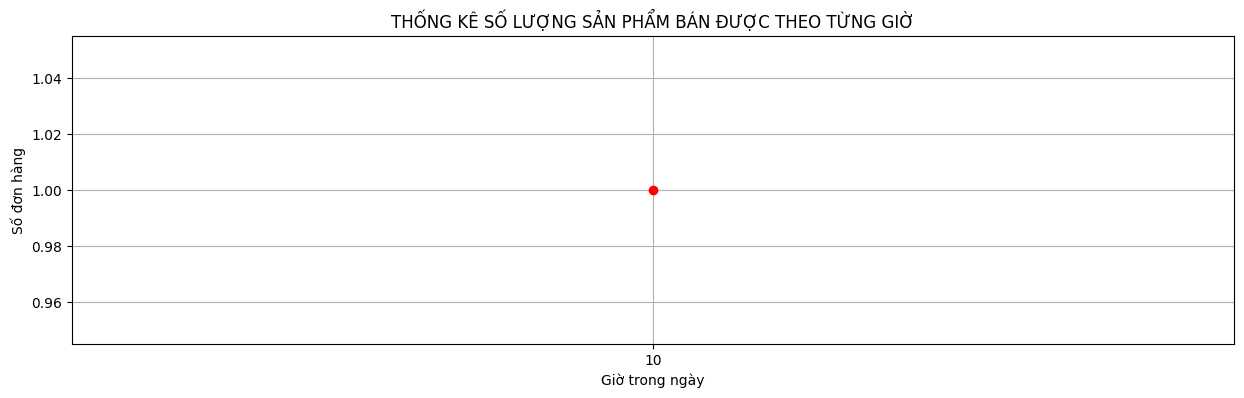

In [133]:
# Lấy trực tiếp các khung giờ có trong dữ liệu thực tế
hours = product_hours.index
products = product_hours['Quantity Ordered'].values

plt.figure(figsize=(15,4))
plt.plot(hours, products, 'r--o')
plt.title('THỐNG KÊ SỐ LƯỢNG SẢN PHẨM BÁN ĐƯỢC THEO TỪNG GIỜ')
plt.xticks(hours)
plt.ylabel('Số đơn hàng')
plt.xlabel('Giờ trong ngày')

plt.grid()
plt.show()

In [134]:
# Đếm số lượng đơn hàng (mỗi dòng dữ liệu hoặc mỗi mã đơn hàng duy nhất) theo từng khung giờ
hourly_orders = all_data.groupby('Hour')['Order ID'].count()

# Tìm giờ có số lượng đơn hàng lớn nhất
if not hourly_orders.empty:
    best_hour = hourly_orders.idxmax()
    max_orders = hourly_orders.max()
    print(f"Khung giờ có nhiều đơn hàng nhất là: {best_hour}h với tổng số {max_orders} đơn hàng.")
    print("\nThống kê số lượng đơn hàng theo từng khung giờ:")
    display(hourly_orders.to_frame(name='Số lượng đơn hàng'))
else:
    print("Không có dữ liệu đơn hàng theo giờ.")

Khung giờ có nhiều đơn hàng nhất là: 10h với tổng số 1 đơn hàng.

Thống kê số lượng đơn hàng theo từng khung giờ:


,Số lượng đơn hàng
Hour,
10,1


In [135]:
unique_products = all_data['Product'].unique()
print("5 sản phẩm đầu tiên trong danh sách duy nhất:")
for product in unique_products[:5]:
    print(f"- {product}")

5 sản phẩm đầu tiên trong danh sách duy nhất:
- Macbook Pro Laptop


In [136]:
# Tính tổng số lượng bán được cho từng sản phẩm và sắp xếp giảm dần
best_selling_products = all_data.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

# Hiển thị sản phẩm bán chạy nhất
if not best_selling_products.empty:
    top_product = best_selling_products.index[0]
    top_quantity = best_selling_products.iloc[0]
    print(f"Sản phẩm bán chạy nhất là: {top_product} với tổng số lượng bán được là {top_quantity} sản phẩm.")
    print("\nBảng thống kê chi tiết:")
    display(best_selling_products.to_frame())
else:
    print("Không có dữ liệu sản phẩm.")

Sản phẩm bán chạy nhất là: Macbook Pro Laptop với tổng số lượng bán được là 1 sản phẩm.

Bảng thống kê chi tiết:


,Quantity Ordered
Product,
Macbook Pro Laptop,1


<img src='https://github.com/Namth20242306M/python/blob/master/Pic/insight.png?raw=1' width='200px' align='left'>


 **NHẬN XÉT 3:**
---
* Khoảng thời gian mua hàng nhiều nhất 10 am --> 21 pm; cao điểm nhất là lúc 12 am và 19 pm

### Câu hỏi 4: Trong các hóa đơn của Khách hàng, Sản phẩm nào thường được mua cùng với nhau?

In [137]:
#Lọc danh sách lấy các hóa đơn mua nhiều sản phẩm
df = all_data[all_data['Order ID'].duplicated(keep=False)]
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,City,Sales


In [138]:
#Ghép các sản phẩm lại với nhau theo từng mã Order ID, để xem sản phẩm nào hay mua cùng với nhau
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

df[['Order ID','Product','Grouped']]

,Order ID,Product,Grouped


In [139]:
#Lấy cột Order ID, Grouped, xóa các hóa đơn lặp lại
df2 = df[['Order ID', 'Grouped']].drop_duplicates()
df2

,Order ID,Grouped


In [140]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df2['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))

for key,value in count.most_common(15):
    print(key, value)

<img src='https://github.com/Namth20242306M/python/blob/master/Pic/insight.png?raw=1' width='200px' align='left'>


 **NHẬN XÉT 4:**
---

Thống kê trong toàn bộ các hóa đơn bán hàng, ta thấy những cặp sản phẩm thường được mua cùng nhau bao gồm
* Phổ biến nhất là người dùng mua iPhone sẽ mua theo -> Lightning Charging Cable, -> Wire Headphone --> Apple Airpods Headphones.
* Người dùng mua Google Phone thường sẽ mua theo --> USB-C Charging Cable --> Wired Headphones --> Bose SoundSport Headphones.
* Người dùng mua Vareebadd Phone thường sẽ mua theo --> USB-C Charging Cable --> Wired Headphones

### Câu hỏi 5: Sản phẩm nào của chuỗi cửa hàng bán chạy nhất? Tại sao nó lại bán được nhiều?
---
Chuỗi cửa hàng điện tử này bán 19 mặt hàng bao gồm:
1. '20in Monitor',
2. '27in 4K Gaming Monitor',
3. '27in FHD Monitor',
4. '34in Ultrawide Monitor',
5. 'AA Batteries (4-pack)',
6. 'AAA Batteries (4-pack)',
7. 'Apple Airpods Headphones',
8. 'Bose SoundSport Headphones',
9. 'Flatscreen TV',
10. 'Google Phone',
11. 'LG Dryer',
12. 'LG Washing Machine',
13. 'Lightning Charging Cable',
14. 'Macbook Pro Laptop',
15. 'ThinkPad Laptop',
16. 'USB-C Charging Cable',
17. 'Vareebadd Phone',
18. 'Wired Headphones',
19. 'iPhone'

In [141]:
#Thống kê số lượng sản phẩm bán được theo mặt hàng
products_count = all_data[['Product','Quantity Ordered']].groupby('Product').sum()
products_count

,Quantity Ordered
Product,
Macbook Pro Laptop,1


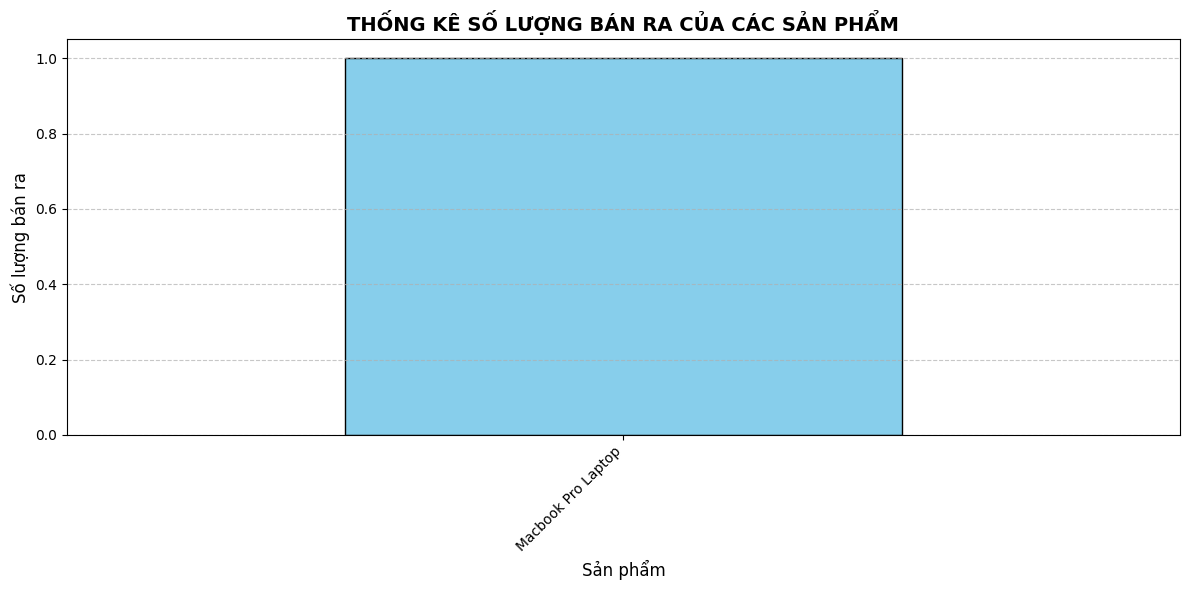

In [142]:
import matplotlib.pyplot as plt

# Tính tổng số lượng bán ra cho mỗi sản phẩm
products_count = all_data.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
products_count.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('THỐNG KÊ SỐ LƯỢNG BÁN RA CỦA CÁC SẢN PHẨM', fontsize=14, fontweight='bold')
plt.xlabel('Sản phẩm', fontsize=12)
plt.ylabel('Số lượng bán ra', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [143]:
# Tính tổng số lượng bán ra cho mỗi sản phẩm và sắp xếp tăng dần để lấy các sản phẩm bán chạy nhất từ dưới lên
least_selling_products = all_data.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=True)

# Xuất 5 sản phẩm có số lượng bán ra thấp nhất
print("5 sản phẩm có số lượng bán ra thấp nhất:")
display(least_selling_products.head(5).to_frame(name='Tổng số lượng bán dắt'))

5 sản phẩm có số lượng bán ra thấp nhất:


,Tổng số lượng bán dắt
Product,
Macbook Pro Laptop,1


In [144]:
import matplotlib.pyplot as plt

# Tính tổng doanh thu và số lượng bán ra theo từng sản phẩm
product_revenue = all_data.groupby('Product').agg(
    Tong_Doanh_Thu=('Sales', 'sum'),
    Tong_So_Luong=('Quantity Ordered', 'sum')
).sort_values(by='Tong_Doanh_Thu', ascending=False)

# Lấy Top 5 sản phẩm có doanh thu cao nhất
top_5_products = product_revenue.head(5)

print("TOP 5 SẢN PHẨM CÓ DOANH THU CAO NHẤT:")
display(top_5_products)


TOP 5 SẢN PHẨM CÓ DOANH THU CAO NHẤT:


,Tong_Doanh_Thu,Tong_So_Luong
Product,,
Macbook Pro Laptop,1700.0,1


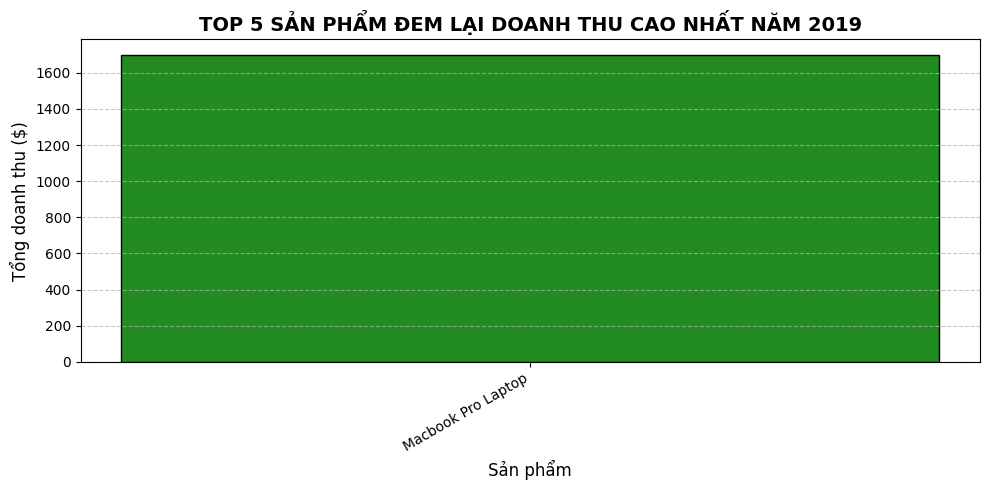

In [145]:
# Trực quan hóa Top 5 sản phẩm đem lại doanh thu lớn nhất
plt.figure(figsize=(10, 5))
plt.bar(top_5_products.index, top_5_products['Tong_Doanh_Thu'], color='forestgreen', edgecolor='black')
plt.title('TOP 5 SẢN PHẨM ĐEM LẠI DOANH THU CAO NHẤT NĂM 2019', fontsize=14, fontweight='bold')
plt.xlabel('Sản phẩm', fontsize=12)
plt.ylabel('Tổng doanh thu ($)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [146]:
# Tính tổng doanh thu và tổng số lượng sản phẩm của tất cả các mặt hàng
total_revenue = all_data['Sales'].sum()
total_quantity = all_data['Quantity Ordered'].sum()

# Tạo DataFrame để hiển thị báo cáo tổng quan
total_stats = pd.DataFrame({
    'Chỉ số': ['Tổng Doanh Thu ($)', 'Tổng Số Lượng Sản Phẩm Bán Ra'],
    'Giá trị': [f"{total_revenue:,.2f}", f"{total_quantity:,}"]
})

display(total_stats)

,Chỉ số,Giá trị
0,Tổng Doanh Thu ($),"1,700.00"
1,Tổng Số Lượng Sản Phẩm Bán Ra,1


In [147]:
# Xuất toàn bộ dữ liệu chi tiết sau phân tích ra file CSV
all_data.to_csv('all_data_final.csv', index=False)
print("Đã lưu file 'all_data_final.csv' thành công!")

# Xuất báo cáo doanh thu & số lượng theo từng sản phẩm ra file CSV
product_revenue.to_csv('product_revenue_report.csv', index=True)
print("Đã lưu file 'product_revenue_report.csv' thành công!")

Đã lưu file 'all_data_final.csv' thành công!
Đã lưu file 'product_revenue_report.csv' thành công!


In [148]:
# Tính tổng doanh thu chung
total_revenue_overall = all_data['Sales'].sum()

# Tính tổng doanh thu theo từng sản phẩm và tính tỷ lệ phần trăm
product_revenue_contribution = all_data.groupby('Product')['Sales'].sum().reset_index()
product_revenue_contribution.columns = ['Sản phẩm', 'Doanh thu ($)']
product_revenue_contribution['Tỷ lệ % doanh thu'] = (product_revenue_contribution['Doanh thu ($)'] / total_revenue_overall) * 100

# Sắp xếp giảm dần theo tỷ lệ đóng góp
product_revenue_contribution = product_revenue_contribution.sort_values(by='Tỷ lệ % doanh thu', ascending=False).reset_index(drop=True)

# Định dạng hiển thị
product_revenue_contribution['Doanh thu ($)'] = product_revenue_contribution['Doanh thu ($)'].map('{:,.2f}'.format)
product_revenue_contribution['Tỷ lệ % doanh thu'] = product_revenue_contribution['Tỷ lệ % doanh thu'].map('{:.2f}%'.format)

display(product_revenue_contribution)

,Sản phẩm,Doanh thu ($),Tỷ lệ % doanh thu
0,Macbook Pro Laptop,"1,700.00",100.00%


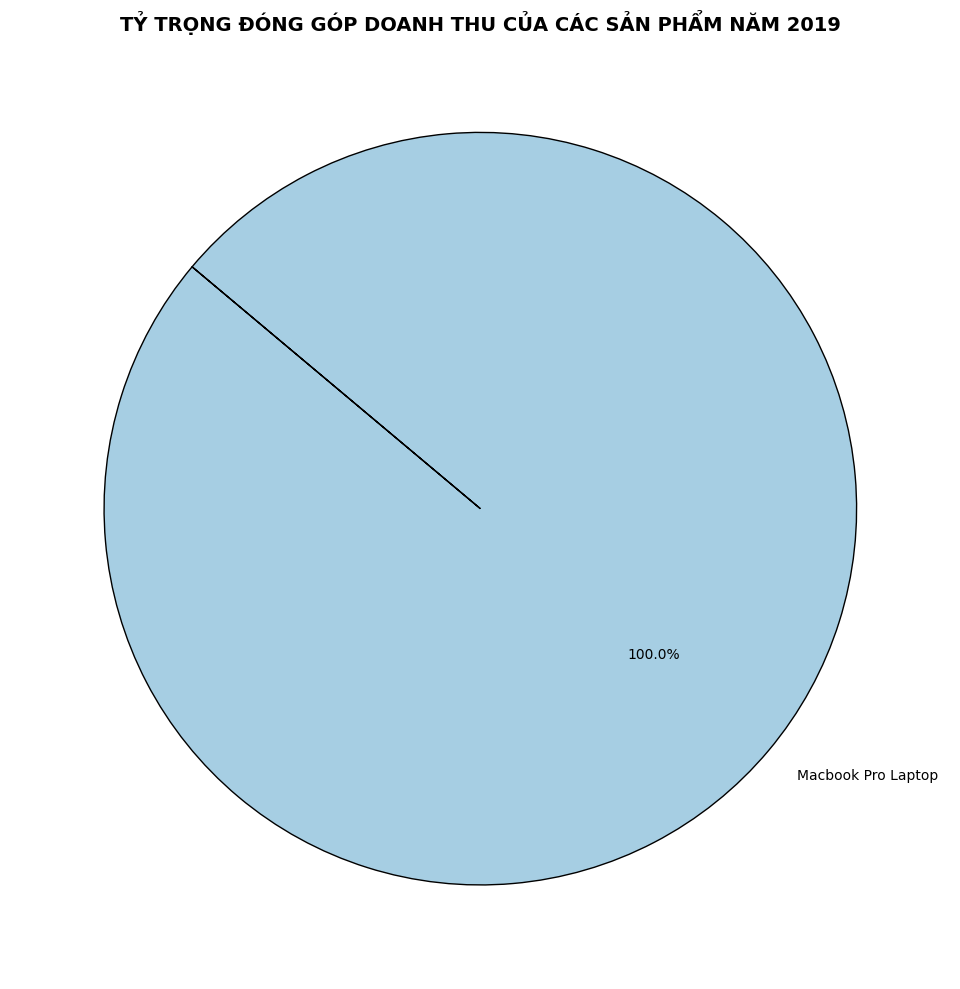

In [149]:
import matplotlib.pyplot as plt

# Chuẩn bị dữ liệu vẽ biểu đồ từ DataFrame tỷ lệ doanh thu đã tính ở bước trước
# Để biểu đồ không bị rối mắt nếu có quá nhiều sản phẩm nhỏ, chúng ta sẽ lấy 5 sản phẩm lớn nhất và gộp các sản phẩm còn lại vào nhóm "Khác"
top_n = 5

if len(product_revenue_contribution) > top_n:
    top_contributors = product_revenue_contribution.head(top_n).copy()

    # Tính tổng của các sản phẩm còn lại
    # Chuyển đổi lại kiểu số từ chuỗi định dạng (nếu cần) để tính toán chính xác
    revenue_converted = product_revenue_contribution['Doanh thu ($)'].str.replace(',', '').astype(float)
    other_revenue = revenue_converted.iloc[top_n:].sum()
    total_all = revenue_converted.sum()
    other_percentage = (other_revenue / total_all) * 100

    # Thêm dòng 'Khác'
    other_row = pd.DataFrame({
        'Sản phẩm': ['Các sản phẩm khác'],
        'Doanh thu ($)': [f"{other_revenue:,.2f}"],
        'Tỷ lệ % doanh thu': [f"{other_percentage:.2f}%"]
    })

    plot_data = pd.concat([top_contributors, other_row], ignore_index=True)
else:
    plot_data = product_revenue_contribution.copy()

# Chuyển đổi cột tỷ lệ về dạng số float để vẽ biểu đồ
plot_data['Pct_Float'] = plot_data['Tỷ lệ % doanh thu'].str.rstrip('%').astype(float)

# Vẽ biểu đồ hình tròn
plt.figure(figsize=(10, 10))
plt.pie(
    plot_data['Pct_Float'],
    labels=plot_data['Sản phẩm'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired(range(len(plot_data))),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
)

plt.title('TỶ TRỌNG ĐÓNG GÓP DOANH THU CỦA CÁC SẢN PHẨM NĂM 2019', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [150]:
# Xuất bảng tỷ lệ phần trăm đóng góp doanh thu của từng sản phẩm ra file CSV
product_revenue_contribution.to_csv('product_revenue_contribution.csv', index=False)
print("Đã lưu file 'product_revenue_contribution.csv' thành công!")

Đã lưu file 'product_revenue_contribution.csv' thành công!


In [151]:
# Tính tổng doanh thu chung của toàn hệ thống
total_sales_system = all_data['Sales'].sum()

# Tổng hợp doanh thu theo từng thành phố
city_revenue_summary = all_data.groupby('City')['Sales'].agg(
    Tong_Doanh_Thu=('sum'),
    So_Luong_Don_Hang=('count')
).reset_index()

# Tính tỷ lệ % đóng góp của từng thành phố
city_revenue_summary['Ty_Le_Dong_Gop (%)'] = (city_revenue_summary['Tong_Doanh_Thu'] / total_sales_system) * 100

# Sắp xếp giảm dần theo doanh thu để tìm thị trường tiềm năng nhất
city_revenue_summary = city_revenue_summary.sort_values(by='Tong_Doanh_Thu', ascending=False).reset_index(drop=True)

# Định dạng hiển thị tiền tệ và phần trăm
city_revenue_summary['Tong_Doanh_Thu ($)'] = city_revenue_summary['Tong_Doanh_Thu'].map('{:,.2f}'.format)
city_revenue_summary['Ty_Le_Dong_Gop (%)'] = city_revenue_summary['Ty_Le_Dong_Gop (%)'].map('{:.2f}%'.format)

# Hiển thị bảng tổng hợp
print("BẢNG THỐNG KÊ DOANH THU THEO TỪNG THÀNH PHỐ:")
display(city_revenue_summary[['City', 'So_Luong_Don_Hang', 'Tong_Doanh_Thu ($)', 'Ty_Le_Dong_Gop (%)']])

BẢNG THỐNG KÊ DOANH THU THEO TỪNG THÀNH PHỐ:


,City,So_Luong_Don_Hang,Tong_Doanh_Thu ($),Ty_Le_Dong_Gop (%)
0,New York City (NY),1,"1,700.00",100.00%


In [152]:
# Gom nhóm theo Tháng và Thành phố để tính tổng doanh thu
monthly_city_revenue = all_data.groupby(['Month', 'City'])['Sales'].sum().reset_index()

# Tìm thành phố có doanh thu lớn nhất trong mỗi tháng
best_city_per_month = monthly_city_revenue.loc[monthly_city_revenue.groupby('Month')['Sales'].idxmax()].reset_index(drop=True)

# Định dạng lại cột hiển thị tiền tệ
best_city_per_month['Doanh thu cao nhất ($)'] = best_city_per_month['Sales'].map('{:,.2f}'.format)
best_city_per_month = best_city_per_month.rename(columns={'Month': 'Tháng', 'City': 'Thành phố'})

print("THÀNH PHỐ CÓ DOANH THU CAO NHẤT THEO TỪNG THÁNG:")
display(best_city_per_month[['Tháng', 'Thành phố', 'Doanh thu cao nhất ($)']])

THÀNH PHỐ CÓ DOANH THU CAO NHẤT THEO TỪNG THÁNG:


,Tháng,Thành phố,Doanh thu cao nhất ($)
0,1,New York City (NY),"1,700.00"


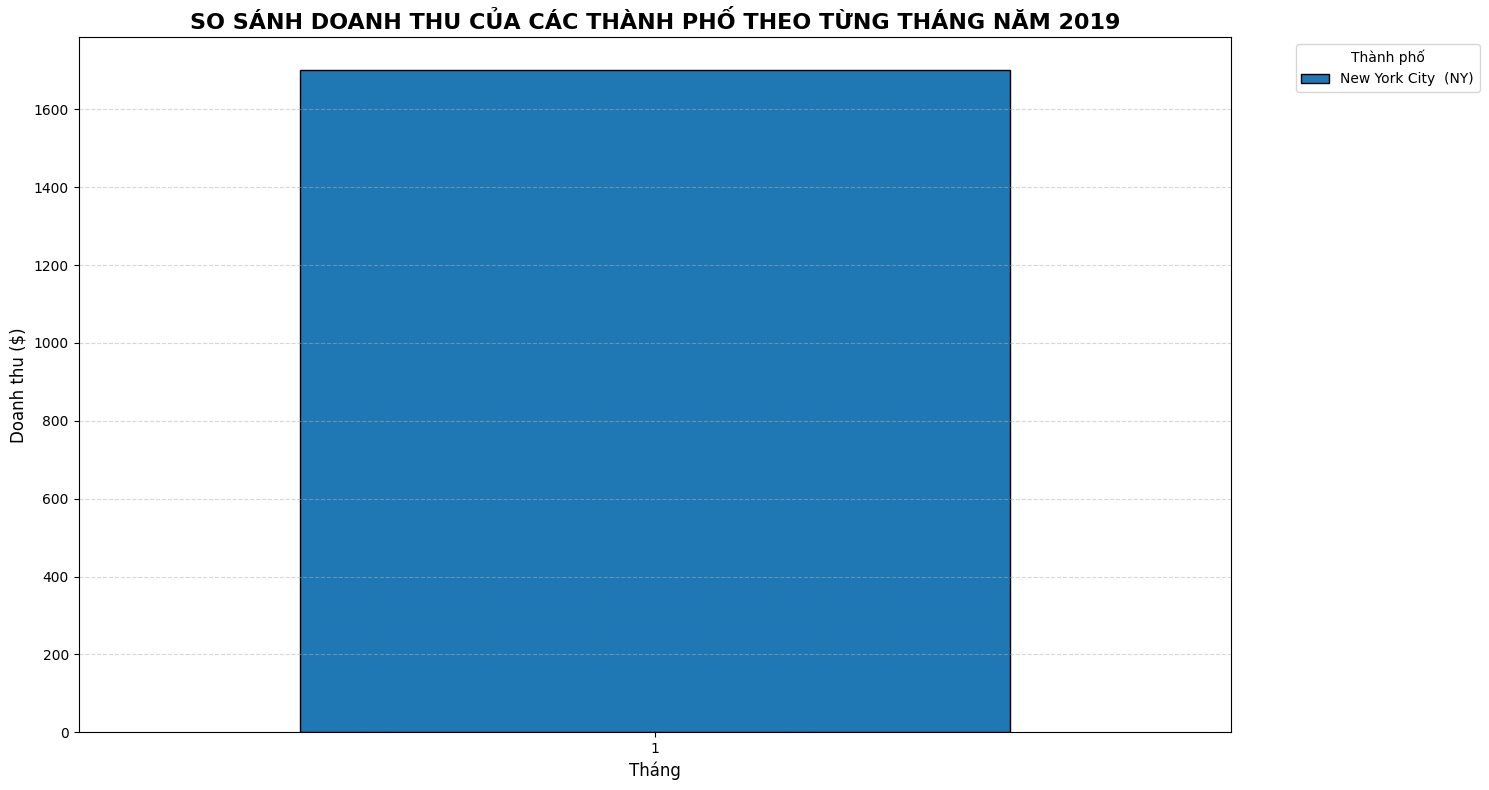

In [153]:
import matplotlib.pyplot as plt

# Gom nhóm theo Tháng và Thành phố để tính tổng doanh thu (khắc phục lỗi NameError)
monthly_city_revenue = all_data.groupby(['Month', 'City'])['Sales'].sum().reset_index()

# Chuẩn bị dữ liệu: Pivot bảng để có Tháng làm chỉ mục (index) và các Thành phố làm các cột
pivot_city_monthly = monthly_city_revenue.pivot(index='Month', columns='City', values='Sales').fillna(0)

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
pivot_city_monthly.plot(kind='bar', figsize=(15, 8), width=0.8, edgecolor='black')

plt.title('SO SÁNH DOANH THU CỦA CÁC THÀNH PHỐ THEO TỪNG THÁNG NĂM 2019', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Thành phố', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [154]:
# Tính tổng doanh thu theo từng sản phẩm và sắp xếp giảm dần
product_revenue_total = all_data.groupby('Product')['Sales'].sum().sort_values(ascending=False).reset_index()
product_revenue_total.columns = ['Sản phẩm', 'Tổng Doanh Thu ($)']

# Định dạng hiển thị tiền tệ
product_revenue_total['Tổng Doanh Thu ($)'] = product_revenue_total['Tổng Doanh Thu ($)'].map('{:,.2f}'.format)

print("TỔNG DOANH THU THEO TỪNG SẢN PHẨM:")
display(product_revenue_total)

TỔNG DOANH THU THEO TỪNG SẢN PHẨM:


,Sản phẩm,Tổng Doanh Thu ($)
0,Macbook Pro Laptop,"1,700.00"


In [155]:
# Kiểm tra các cột và kiểu dữ liệu hiện tại của all_data
print("Danh sách các cột trong all_data:")
print(all_data.columns.tolist())

# Hiển thị thông tin tổng quát và 5 dòng đầu tiên
all_data.info()
display(all_data.head())

Danh sách các cột trong all_data:
['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Hour', 'City', 'Sales']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1 non-null      int64         
 1   Product           1 non-null      object        
 2   Quantity Ordered  1 non-null      int64         
 3   Price Each        1 non-null      float64       
 4   Order Date        1 non-null      datetime64[ns]
 5   Purchase Address  1 non-null      object        
 6   Month             1 non-null      int32         
 7   Hour              1 non-null      int32         
 8   City              1 non-null      object        
 9   Sales             1 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2), object(3)
memory usage: 204.0+ b

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,City,Sales
0,12345,Macbook Pro Laptop,1,1700.0,2019-01-01 10:00:00,"123 Main St, New York City, NY",1,10,New York City (NY),1700.0


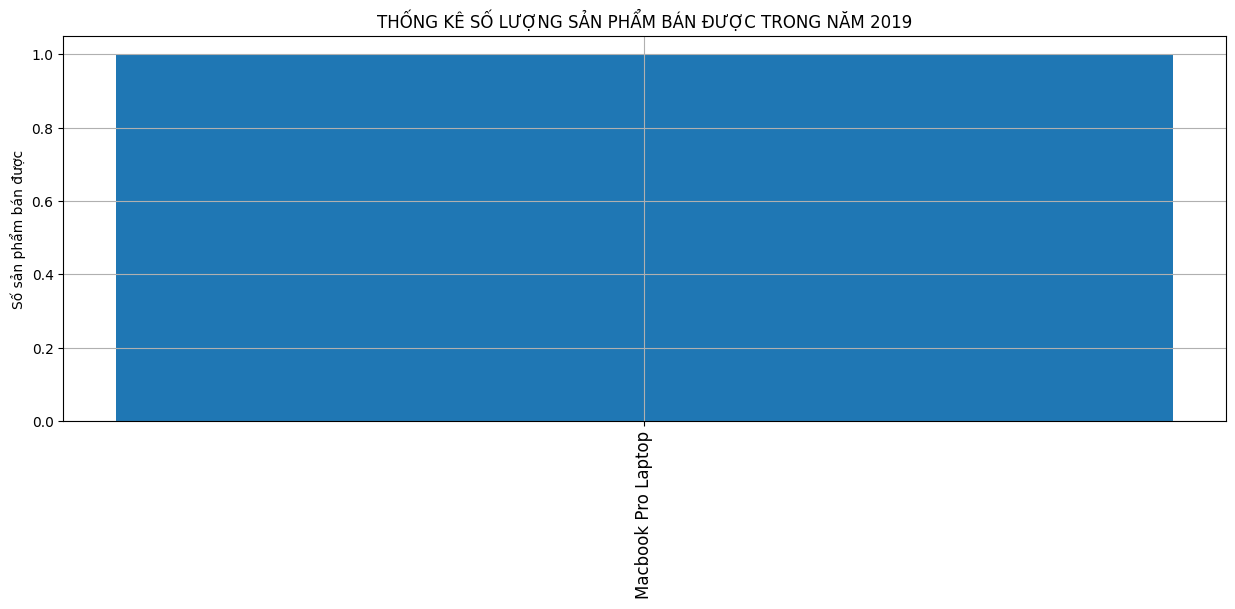

In [156]:
#Trực quan hóa dữ liệu
#Tách dữ liệu để hiển thị
product_names = products_count.index
product_num = products_count.values.ravel()


plt.figure(figsize=(15,5))
plt.bar(product_names, product_num)
plt.ylabel('Số sản phẩm bán được')
plt.xticks(product_names, rotation=90, size=12)
plt.title('THỐNG KÊ SỐ LƯỢNG SẢN PHẨM BÁN ĐƯỢC TRONG NĂM 2019')
plt.grid(True)
plt.show()


In [157]:
#Trực quan hóa thêm giá tương ứng của mỗi sản phẩm vào đồ thị
prices = all_data.groupby('Product').mean()['Price Each']

fig, ax1 = plt.subplots(figsize=(15,5))

ax2 = ax1.twinx()
ax1.bar(product_names, product_num, color='g')
ax2.plot(product_names, prices, 'b-o')

ax1.set_title('BIỂU ĐỒ THỂ HIỆN SỐ LƯỢNG SẢN PHẨM BÁN ĐƯỢC VÀ GIÁ CỦA MẶT HÀNG ĐÓ')
ax1.set_ylabel('Số sản phẩm bán được', color='g')
ax2.set_ylabel('Giá sản phẩm ($)', color='b')
ax1.set_xticklabels(product_names, rotation='vertical', size=8)
ax1.grid(True)
fig.show()

TypeError: agg function failed [how->mean,dtype->object]

<img src='https://github.com/Namth20242306M/python/blob/master/Pic/insight.png?raw=1' width='200px' align='left'>


 **NHẬN XÉT 5:**
---

* Trong số các sản phẩm được bán, các mặt hàng bán được số lượng nhiều nhất bao gồm: AA Batteries (4-pack), AA Batteries (4-pack); USB-C Charging Cable; Lightning Charging Cable; Wired Headphones; --> Lý do: Giá bán các mặt hàng này trên  mỗi sản phẩm thấp.
* Các sản phẩm bán được số lượng ít nhất bao gồm: LG Dryer; LG Washing Machine; Vareebadd Phone; 20in Monitor;ThinkPad Laptop --> Một trong số các lý do: Giá bán cao




<img src='https://github.com/Namth20242306M/python/blob/master/Pic/action.jpg?raw=1' width='700px'>